# Dataset-wide PPG filter evaluation

Evaluate the 0.5--8 Hz, order-2, zero-phase Butterworth filter across all sessions.

In [1]:
# Setup: imports and shared configuration
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import trapezoid
from scipy.signal import find_peaks, welch


def find_project_root(start: Path) -> Path:
    """Find the phase1 project root."""
    candidates = (start, *start.parents)
    for candidate in candidates:
        if (candidate / "src" / "dataloader").is_dir():
            return candidate
        phase1_dir = candidate / "phase1"
        if (phase1_dir / "src" / "dataloader").is_dir():
            return phase1_dir
    raise FileNotFoundError("Cannot locate the phase1 project root")


def natural_file_key(path: Path) -> list[str | int]:
    """Sort file names in natural numeric order."""
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", path.name)
    ]


def summarize_metrics(
    frame: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """Summarize numeric metrics."""
    rows = []
    for column in columns:
        values = frame[column].dropna()
        rows.append({
            "Metric": column,
            "Median": values.median(),
            "IQR": values.quantile(0.75) - values.quantile(0.25),
            "Min": values.min(),
            "Max": values.max(),
        })
    return pd.DataFrame(rows)


def iqr_outlier_mask(
    values: pd.Series,
    direction: str = "both",
) -> pd.Series:
    """Flag values outside 1.5 IQR fences."""
    valid = values.dropna()
    if valid.empty:
        return pd.Series(False, index=values.index)
    first_quartile, third_quartile = valid.quantile([0.25, 0.75])
    spread = third_quartile - first_quartile
    lower = first_quartile - 1.5 * spread
    upper = third_quartile + 1.5 * spread
    if direction == "low":
        return values < lower
    if direction == "high":
        return values > upper
    return (values < lower) | (values > upper)


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from dataloader.loader import load_session  # noqa: E402
from preprocessing.filter import preprocess_ppg  # noqa: E402

LOWCUT_HZ = 0.5
HIGHCUT_HZ = 8.0
FILTER_ORDER = 2
PEAK_MIN_DISTANCE_S = 0.3
PEAK_PROMINENCE_FRACTION = 0.1
PEAK_MATCH_TOLERANCE_S = 0.1
WAVEFORM_START_S = 10.0
WAVEFORM_END_S = 30.0
FS_GROUP_TOLERANCE_HZ = 1.0

mpl.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "figure.dpi": 120,
    "font.size": 9,
})

In [2]:
# Cell 1: Load all sessions and inspect inputs
def estimate_sampling_rate(time_s: np.ndarray) -> float:
    """Estimate sampling rate from the median positive interval."""
    intervals = np.diff(time_s)
    valid_intervals = intervals[np.isfinite(intervals) & (intervals > 0)]
    if valid_intervals.size == 0:
        raise ValueError("Time axis has no positive finite interval")
    return float(1.0 / np.median(valid_intervals))


def sampling_group(fs: float) -> str:
    """Assign a nominal sampling-rate group."""
    for nominal_fs in (25.0, 50.0):
        if abs(fs - nominal_fs) <= FS_GROUP_TOLERANCE_HZ:
            return f"{int(nominal_fs)} Hz"
    return "Other"


DATASET_DIR = PROJECT_ROOT / "dataset" / "dhdata"
csv_paths = sorted(DATASET_DIR.glob("*.csv"), key=natural_file_key)
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in {DATASET_DIR}")

sessions = []
load_failures = []
for csv_path in csv_paths:
    try:
        frame, metadata = load_session(csv_path)
        time_s = pd.to_numeric(frame["Time (s)"], errors="coerce").to_numpy()
        raw_ppg = pd.to_numeric(
            frame["IR Value raw"], errors="coerce"
        ).to_numpy()
        labels = frame["Label"].to_numpy(copy=True)
        if not np.all(np.isfinite(time_s)):
            raise ValueError("Time axis contains NaN or Inf")
        if not np.all(np.isfinite(raw_ppg)):
            raise ValueError("Raw PPG contains NaN or Inf")
        fs = estimate_sampling_rate(time_s)
        duration_s = float(time_s[-1] - time_s[0])
    except (FileNotFoundError, IndexError, TypeError, ValueError) as exc:
        load_failures.append({
            "Session": csv_path.name,
            "Reason": str(exc),
        })
        continue
    sessions.append({
        "session": metadata["file_name"],
        "frame": frame,
        "time": time_s,
        "raw": raw_ppg,
        "labels": labels,
        "fs": fs,
        "sampling_group": sampling_group(fs),
        "duration_s": duration_s,
    })

input_table = pd.DataFrame([{
    "Session": item["session"],
    "Samples": len(item["raw"]),
    "Duration (s)": item["duration_s"],
    "Estimated fs (Hz)": item["fs"],
} for item in sessions])
print(f"Loaded sessions: {len(sessions)} / {len(csv_paths)}")
display(input_table.style.format({
    "Duration (s)": "{:.2f}",
    "Estimated fs (Hz)": "{:.3f}",
}).hide(axis="index"))
if load_failures:
    display(pd.DataFrame(load_failures).style.hide(axis="index"))

Loaded sessions: 20 / 20


Session,Samples,Duration (s),Estimated fs (Hz)
sample_1.csv,117828,2356.54,50.000
sample_4.csv,75416,3028.69,24.992
sample_5.csv,91211,3650.87,25.003
sample_6.csv,79179,3179.80,24.993
sample_7.csv,79768,3203.50,24.994
sample_8.csv,77595,3116.19,24.994
sample_9.csv,119272,4747.33,25.001
sample_10.csv,60386,2425.13,24.998
sample_11.csv,61582,2472.91,24.994
sample_12.csv,89853,3608.36,24.989


In [3]:
# Cell 2: Apply the filter to the full dataset
filtered_sessions = []
filter_failures = []
for item in sessions:
    try:
        inverted, filtered = preprocess_ppg(
            item["raw"],
            item["fs"],
            lowcut=LOWCUT_HZ,
            highcut=HIGHCUT_HZ,
            order=FILTER_ORDER,
        )
        if inverted.shape != item["raw"].shape:
            raise ValueError("Inversion changed the signal length")
        if filtered.shape != item["raw"].shape:
            raise ValueError("Filtering changed the signal length")
        if not np.all(np.isfinite(filtered)):
            raise ValueError("Filtered signal contains NaN or Inf")
    except (FloatingPointError, TypeError, ValueError) as exc:
        filter_failures.append({
            "Session": item["session"],
            "Reason": str(exc),
        })
        continue
    item["inverted"] = inverted
    item["filtered"] = filtered
    filtered_sessions.append(item)

print(f"Successfully filtered: {len(filtered_sessions)} / {len(sessions)}")
if filter_failures:
    display(pd.DataFrame(filter_failures).style.hide(axis="index"))
else:
    print("No filtering errors or non-finite outputs detected.")

Successfully filtered: 20 / 20
No filtering errors or non-finite outputs detected.


In [4]:
# Cell 3: Calculate PSD metrics per session
def estimate_psd(signal: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    """Estimate a Welch power spectral density."""
    segment_length = min(len(signal), max(256, int(round(16 * fs))))
    return welch(signal, fs=fs, nperseg=segment_length, detrend="constant")


def integrate_band(
    frequencies: np.ndarray,
    psd: np.ndarray,
    mask: np.ndarray,
) -> float:
    """Integrate PSD values selected by a frequency mask."""
    if np.count_nonzero(mask) < 2:
        return np.nan
    return float(trapezoid(psd[mask], frequencies[mask]))


def power_ratio(numerator: float, denominator: float) -> float:
    """Return a finite power ratio when defined."""
    if not np.isfinite(denominator) or denominator <= 0:
        return np.nan
    return numerator / denominator


spectral_rows = []
for item in filtered_sessions:
    frequencies, before_psd = estimate_psd(item["inverted"], item["fs"])
    _, after_psd = estimate_psd(item["filtered"], item["fs"])
    band_masks = {
        "in_band": (frequencies >= LOWCUT_HZ)
        & (frequencies <= HIGHCUT_HZ),
        "low": frequencies < LOWCUT_HZ,
        "high": frequencies > HIGHCUT_HZ,
    }
    before_power = {
        name: integrate_band(frequencies, before_psd, mask)
        for name, mask in band_masks.items()
    }
    after_power = {
        name: integrate_band(frequencies, after_psd, mask)
        for name, mask in band_masks.items()
    }
    spectral_rows.append({
        "Session": item["session"],
        "Estimated fs (Hz)": item["fs"],
        "Sampling rate": item["sampling_group"],
        "In-band retention": power_ratio(
            after_power["in_band"], before_power["in_band"]
        ),
        "Low-frequency ratio": power_ratio(
            after_power["low"], before_power["low"]
        ),
        "High-frequency ratio": power_ratio(
            after_power["high"], before_power["high"]
        ),
    })

spectral_metrics = pd.DataFrame(spectral_rows)
spectral_metrics["Low-frequency suppression"] = (
    1.0 - spectral_metrics["Low-frequency ratio"]
)
spectral_metrics["High-frequency suppression"] = (
    1.0 - spectral_metrics["High-frequency ratio"]
)
display(spectral_metrics[[
    "Session",
    "In-band retention",
    "Low-frequency ratio",
    "High-frequency ratio",
]].style.format({
    "In-band retention": "{:.4f}",
    "Low-frequency ratio": "{:.4f}",
    "High-frequency ratio": "{:.4f}",
}).hide(axis="index"))

Session,In-band retention,Low-frequency ratio,High-frequency ratio
sample_1.csv,0.9630,0.0015,0.1060
sample_4.csv,0.9772,0.0057,0.0700
sample_5.csv,0.9454,0.0032,0.0636
sample_6.csv,0.9736,0.0044,0.0613
sample_7.csv,0.9812,0.0018,0.0583
sample_8.csv,0.9766,0.0048,0.0618
sample_9.csv,0.9842,0.0012,0.0760
sample_10.csv,0.9727,0.0058,0.0608
sample_11.csv,0.9751,0.0037,0.0692
sample_12.csv,0.9862,0.0032,0.0659


Metric,Median,IQR,Min,Max
In-band retention,0.9774,0.0091,0.9454,0.9875
Low-frequency suppression,0.9965,0.0019,0.9918,0.9988
High-frequency suppression,0.9345,0.0103,0.8940,0.9465


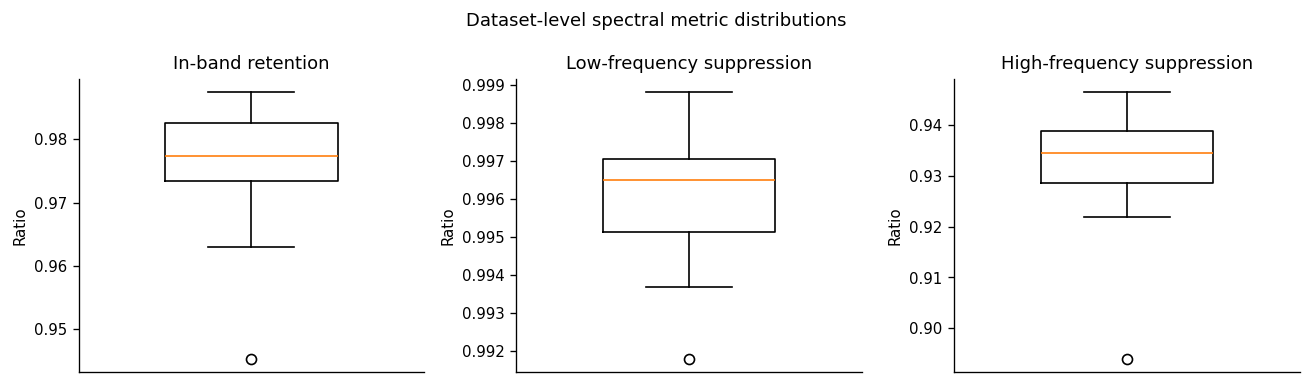

In [5]:
# Cell 4: Summarize spectral metrics across the dataset
spectral_summary_columns = [
    "In-band retention",
    "Low-frequency suppression",
    "High-frequency suppression",
]
spectral_summary = summarize_metrics(
    spectral_metrics, spectral_summary_columns
)
display(spectral_summary.style.format({
    column: "{:.4f}" for column in ["Median", "IQR", "Min", "Max"]
}).hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for axis, column in zip(axes, spectral_summary_columns):
    axis.boxplot(spectral_metrics[column].dropna(), widths=0.5)
    axis.set_title(column)
    axis.set_xticks([])
    axis.set_ylabel("Ratio")
fig.suptitle("Dataset-level spectral metric distributions")
fig.tight_layout()
plt.show()

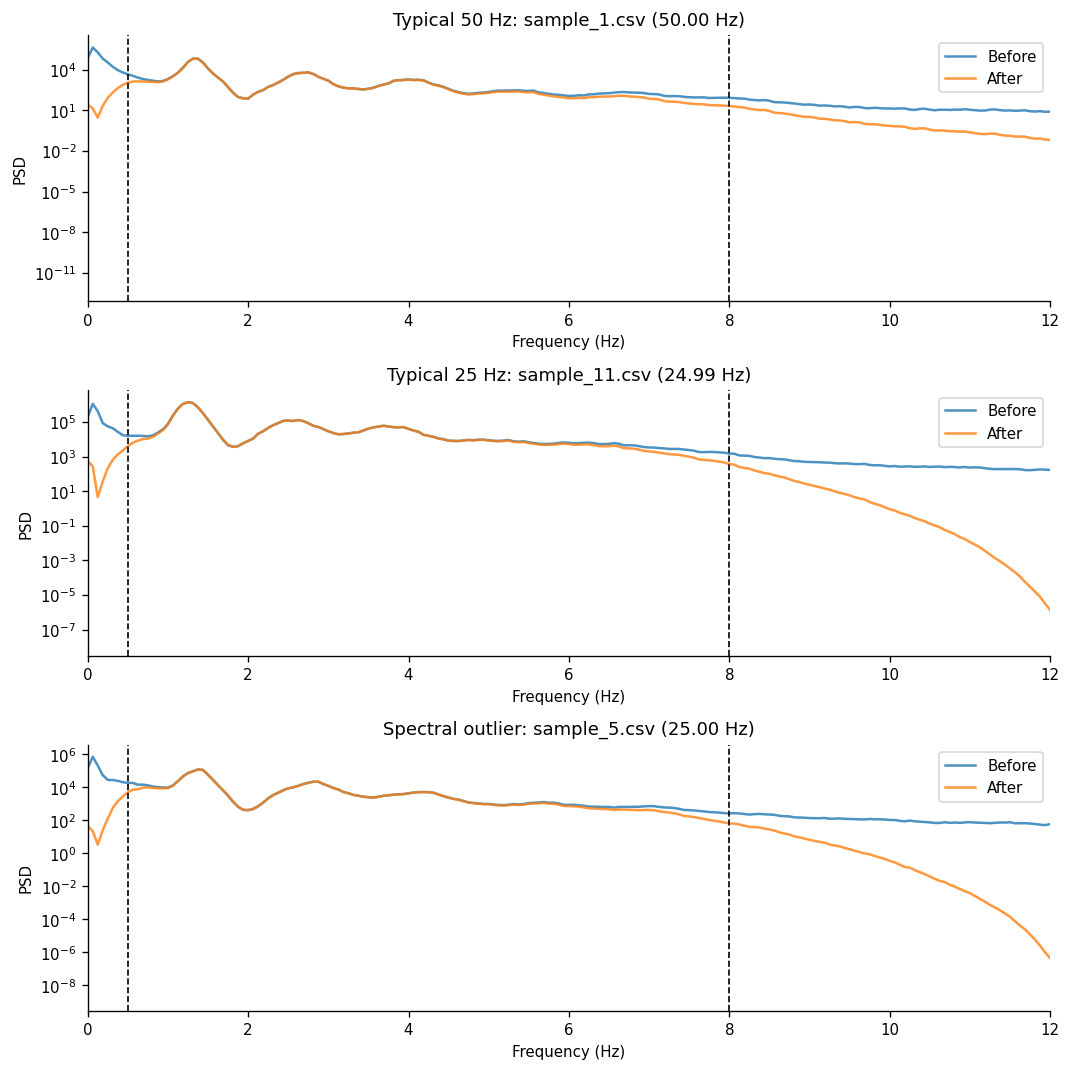

In [6]:
# Cell 5: Compare PSD before and after filtering
def typical_session_name(group: pd.DataFrame) -> str | None:
    """Select the session nearest its group medians."""
    if group.empty:
        return None
    columns = [
        "In-band retention",
        "Low-frequency ratio",
        "High-frequency ratio",
    ]
    medians = group[columns].median()
    scales = group[columns].quantile(0.75) - group[columns].quantile(0.25)
    scales = scales.mask(scales == 0, 1.0)
    distances = ((group[columns] - medians) / scales).abs().sum(axis=1)
    return str(group.loc[distances.idxmin(), "Session"])


spectral_outlier_mask = (
    iqr_outlier_mask(spectral_metrics["In-band retention"], "low")
    | iqr_outlier_mask(spectral_metrics["Low-frequency ratio"])
    | iqr_outlier_mask(spectral_metrics["High-frequency ratio"])
)
representative_names = {
    "Typical 50 Hz": typical_session_name(
        spectral_metrics[spectral_metrics["Sampling rate"] == "50 Hz"]
    ),
    "Typical 25 Hz": typical_session_name(
        spectral_metrics[spectral_metrics["Sampling rate"] == "25 Hz"]
    ),
}
spectral_outliers = spectral_metrics[spectral_outlier_mask]
if not spectral_outliers.empty:
    representative_names["Spectral outlier"] = str(
        spectral_outliers.sort_values("In-band retention").iloc[0]["Session"]
    )
representative_names = {
    label: name for label, name in representative_names.items() if name is not None
}
session_lookup = {item["session"]: item for item in filtered_sessions}

fig, axes = plt.subplots(
    len(representative_names),
    1,
    figsize=(9, 3 * len(representative_names)),
    squeeze=False,
)
for axis, (label, session_name) in zip(axes.flat, representative_names.items()):
    item = session_lookup[session_name]
    frequencies, before_psd = estimate_psd(item["inverted"], item["fs"])
    _, after_psd = estimate_psd(item["filtered"], item["fs"])
    axis.semilogy(frequencies, before_psd, label="Before", alpha=0.8)
    axis.semilogy(frequencies, after_psd, label="After", alpha=0.8)
    axis.axvline(LOWCUT_HZ, color="black", linestyle="--", linewidth=1)
    axis.axvline(HIGHCUT_HZ, color="black", linestyle="--", linewidth=1)
    axis.set_xlim(0, min(12, item["fs"] / 2))
    axis.set_title(f"{label}: {session_name} ({item['fs']:.2f} Hz)")
    axis.set_xlabel("Frequency (Hz)")
    axis.set_ylabel("PSD")
    axis.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Cell 6: Evaluate peak-count consistency
# def detect_diagnostic_peaks(signal: np.ndarray, fs: float) -> np.ndarray:
#     """Detect diagnostic peaks with scale-adaptive prominence."""
#     robust_range = np.quantile(signal, 0.95) - np.quantile(signal, 0.05)
#     prominence = max(PEAK_PROMINENCE_FRACTION * robust_range, np.finfo(float).eps)
#     min_distance = max(1, int(round(PEAK_MIN_DISTANCE_S * fs)))
#     peaks, _ = find_peaks(
#         signal,
#         distance=min_distance,
#         prominence=prominence,
#     )
#     return peaks

def detect_diagnostic_peaks(signal: np.ndarray, fs: float) -> np.ndarray:
    """Detect diagnostic systolic peaks."""

    robust_range = np.quantile(signal, 0.95) - np.quantile(signal, 0.05)
    prominence = max(
        PEAK_PROMINENCE_FRACTION * robust_range,
        np.finfo(float).eps,
    )

    min_distance = max(1, int(round(0.40 * fs)))

    peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence,
    )

    return peaks
peak_count_rows = []
for item in filtered_sessions:
    peaks_before = detect_diagnostic_peaks(item["inverted"], item["fs"])
    peaks_after = detect_diagnostic_peaks(item["filtered"], item["fs"])
    item["peaks_before"] = peaks_before
    item["peaks_after"] = peaks_after
    count_before = len(peaks_before)
    count_after = len(peaks_after)
    change_percent = (
        100.0 * (count_after - count_before) / count_before
        if count_before
        else np.nan
    )
    peak_count_rows.append({
        "Session": item["session"],
        "Peaks before": count_before,
        "Peaks after": count_after,
        "Peak-count difference": count_after - count_before,
        "Peak-count change (%)": change_percent,
    })

peak_count_metrics = pd.DataFrame(peak_count_rows)
display(peak_count_metrics.style.format({
    "Peak-count change (%)": "{:.2f}",
}).hide(axis="index"))
print("Diagnostic detector only; it is not the final PPI detector.")

Session,Peaks before,Peaks after,Peak-count difference,Peak-count change (%)
sample_1.csv,2272,3215,943,41.51
sample_4.csv,4073,4264,191,4.69
sample_5.csv,633,5015,4382,692.26
sample_6.csv,3980,4074,94,2.36
sample_7.csv,4544,5221,677,14.90
sample_8.csv,3924,4045,121,3.08
sample_9.csv,6838,7427,589,8.61
sample_10.csv,2951,3046,95,3.22
sample_11.csv,3145,3203,58,1.84
sample_12.csv,5560,5908,348,6.26


Diagnostic detector only; it is not the final PPI detector.


In [8]:
# Cell 7: Evaluate peak-timing consistency
def match_peak_times(
    before_times: np.ndarray,
    after_times: np.ndarray,
    tolerance_s: float,
) -> np.ndarray:
    """Match ordered peaks one-to-one within a tolerance."""
    before_index = 0
    after_index = 0
    shifts = []
    while before_index < len(before_times) and after_index < len(after_times):
        delta = after_times[after_index] - before_times[before_index]
        if abs(delta) <= tolerance_s:
            shifts.append(abs(delta))
            before_index += 1
            after_index += 1
        elif delta < 0:
            after_index += 1
        else:
            before_index += 1
    return np.asarray(shifts)


peak_timing_rows = []
for item in filtered_sessions:
    before_times = item["time"][item["peaks_before"]]
    after_times = item["time"][item["peaks_after"]]
    shifts_s = match_peak_times(
        before_times, after_times, PEAK_MATCH_TOLERANCE_S
    )
    matched_count = len(shifts_s)
    match_rate = (
        100.0 * matched_count / len(before_times)
        if len(before_times)
        else np.nan
    )
    peak_timing_rows.append({
        "Session": item["session"],
        "Matched peaks": matched_count,
        "Peak match rate (%)": match_rate,
        "Median timing shift (ms)": (
            1_000 * np.median(shifts_s) if matched_count else np.nan
        ),
        "Maximum timing shift (ms)": (
            1_000 * np.max(shifts_s) if matched_count else np.nan
        ),
    })

peak_timing_metrics = pd.DataFrame(peak_timing_rows)
display(peak_timing_metrics.style.format({
    "Peak match rate (%)": "{:.2f}",
    "Median timing shift (ms)": "{:.2f}",
    "Maximum timing shift (ms)": "{:.2f}",
}).hide(axis="index"))

Session,Matched peaks,Peak match rate (%),Median timing shift (ms),Maximum timing shift (ms)
sample_1.csv,2247,98.90,0.00,100.00
sample_4.csv,4069,99.90,0.00,80.46
sample_5.csv,633,100.00,0.00,80.21
sample_6.csv,3980,100.00,0.00,50.59
sample_7.csv,4533,99.76,0.00,80.10
sample_8.csv,3924,100.00,0.00,50.24
sample_9.csv,6838,100.00,0.00,50.87
sample_10.csv,2951,100.00,0.00,50.34
sample_11.csv,3143,99.94,0.00,80.63
sample_12.csv,5560,100.00,0.00,50.76


Metric,Median,IQR,Min,Max
Peak-count change (%),3.95,7.30,0.23,692.26
Peak match rate (%),99.94,0.12,98.90,100.00
Median timing shift (ms),0.00,0.00,0.00,0.00


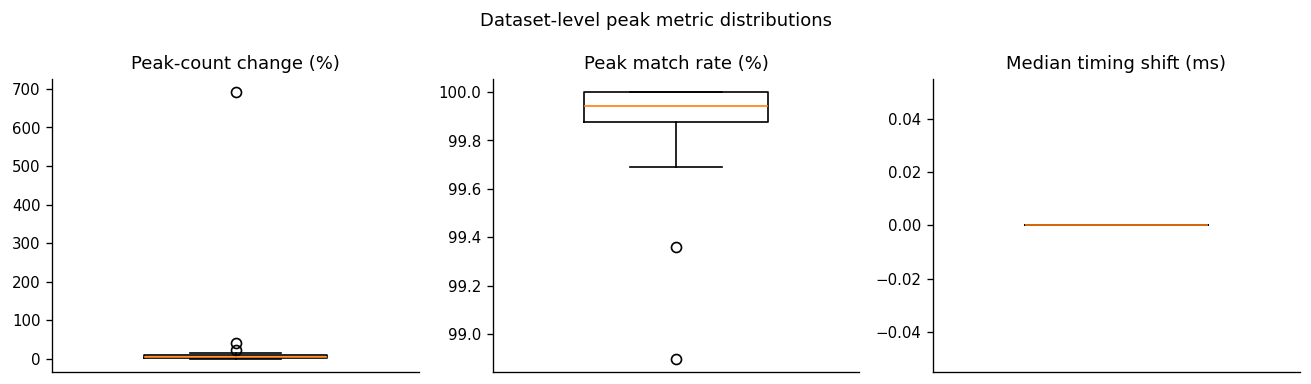

In [9]:
# Cell 8: Summarize peak metrics across the dataset
peak_metrics = peak_count_metrics.merge(peak_timing_metrics, on="Session")
peak_summary_columns = [
    "Peak-count change (%)",
    "Peak match rate (%)",
    "Median timing shift (ms)",
]
peak_summary = summarize_metrics(peak_metrics, peak_summary_columns)
display(peak_summary.style.format({
    column: "{:.2f}" for column in ["Median", "IQR", "Min", "Max"]
}).hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for axis, column in zip(axes, peak_summary_columns):
    axis.boxplot(peak_metrics[column].dropna(), widths=0.5)
    axis.set_title(column)
    axis.set_xticks([])
fig.suptitle("Dataset-level peak metric distributions")
fig.tight_layout()
plt.show()

In [10]:
# Cell 9: Identify sessions for manual inspection
evaluation_metrics = spectral_metrics.merge(peak_metrics, on="Session")
evaluation_metrics["Low in-band retention"] = iqr_outlier_mask(
    evaluation_metrics["In-band retention"], "low"
)
evaluation_metrics["Unusual low-frequency ratio"] = iqr_outlier_mask(
    evaluation_metrics["Low-frequency ratio"]
)
evaluation_metrics["Unusual high-frequency ratio"] = iqr_outlier_mask(
    evaluation_metrics["High-frequency ratio"]
)
absolute_count_change = evaluation_metrics["Peak-count change (%)"].abs()
evaluation_metrics["Large peak-count change"] = iqr_outlier_mask(
    absolute_count_change, "high"
)
evaluation_metrics["Low peak match rate"] = iqr_outlier_mask(
    evaluation_metrics["Peak match rate (%)"], "low"
)
evaluation_metrics["Large timing shift"] = iqr_outlier_mask(
    evaluation_metrics["Median timing shift (ms)"], "high"
)

spectral_flag_columns = [
    "Low in-band retention",
    "Unusual low-frequency ratio",
    "Unusual high-frequency ratio",
]
peak_flag_columns = [
    "Large peak-count change",
    "Low peak match rate",
    "Large timing shift",
]
evaluation_metrics["Spectral outlier"] = evaluation_metrics[
    spectral_flag_columns
].any(axis=1)
evaluation_metrics["Peak-consistency outlier"] = evaluation_metrics[
    peak_flag_columns
].any(axis=1)
all_flag_columns = spectral_flag_columns + peak_flag_columns
evaluation_metrics["Reasons"] = evaluation_metrics.apply(
    lambda row: "; ".join(
        column for column in all_flag_columns if row[column]
    ),
    axis=1,
)
outlier_table = evaluation_metrics[
    evaluation_metrics["Spectral outlier"]
    | evaluation_metrics["Peak-consistency outlier"]
].copy()
outlier_columns = [
    "Session",
    "In-band retention",
    "Low-frequency ratio",
    "High-frequency ratio",
    "Peak-count change (%)",
    "Peak match rate (%)",
    "Median timing shift (ms)",
    "Reasons",
]
if outlier_table.empty:
    print("No sessions crossed the 1.5 IQR outlier fences.")
else:
    display(outlier_table[outlier_columns].style.format({
        "In-band retention": "{:.4f}",
        "Low-frequency ratio": "{:.4f}",
        "High-frequency ratio": "{:.4f}",
        "Peak-count change (%)": "{:.2f}",
        "Peak match rate (%)": "{:.2f}",
        "Median timing shift (ms)": "{:.2f}",
    }).hide(axis="index"))
print("Outliers are flagged for review, not removed.")

Session,In-band retention,Low-frequency ratio,High-frequency ratio,Peak-count change (%),Peak match rate (%),Median timing shift (ms),Reasons
sample_1.csv,0.9630,0.0015,0.1060,41.51,98.90,0.00,Unusual high-frequency ratio; Large peak-count change; Low peak match rate
sample_5.csv,0.9454,0.0032,0.0636,692.26,100.00,0.00,Low in-band retention; Large peak-count change
sample_14.csv,0.9824,0.0032,0.0652,21.59,99.96,0.00,Large peak-count change
sample_23.csv,0.9679,0.0082,0.0535,1.23,99.36,0.00,Unusual low-frequency ratio; Low peak match rate


Outliers are flagged for review, not removed.


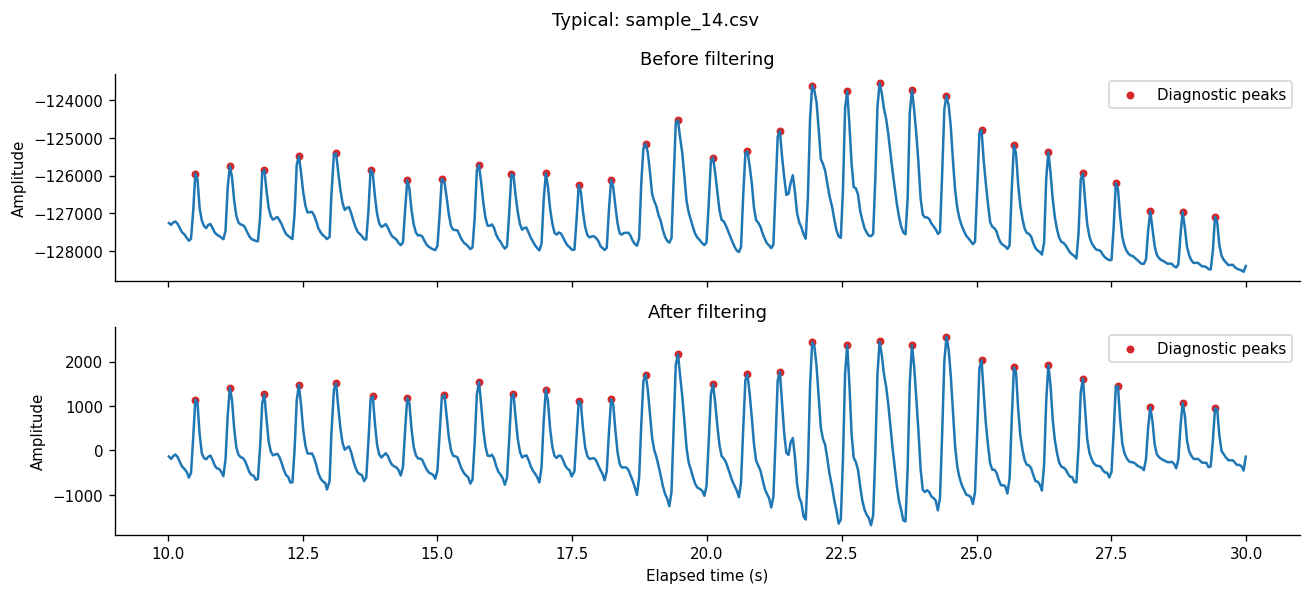

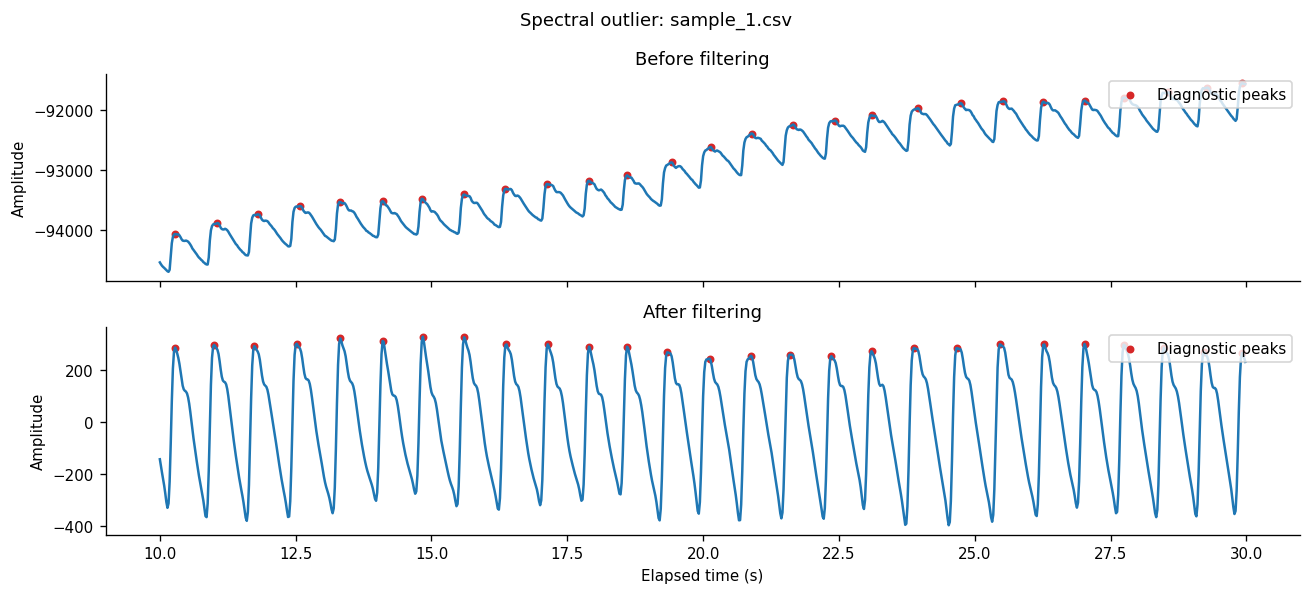

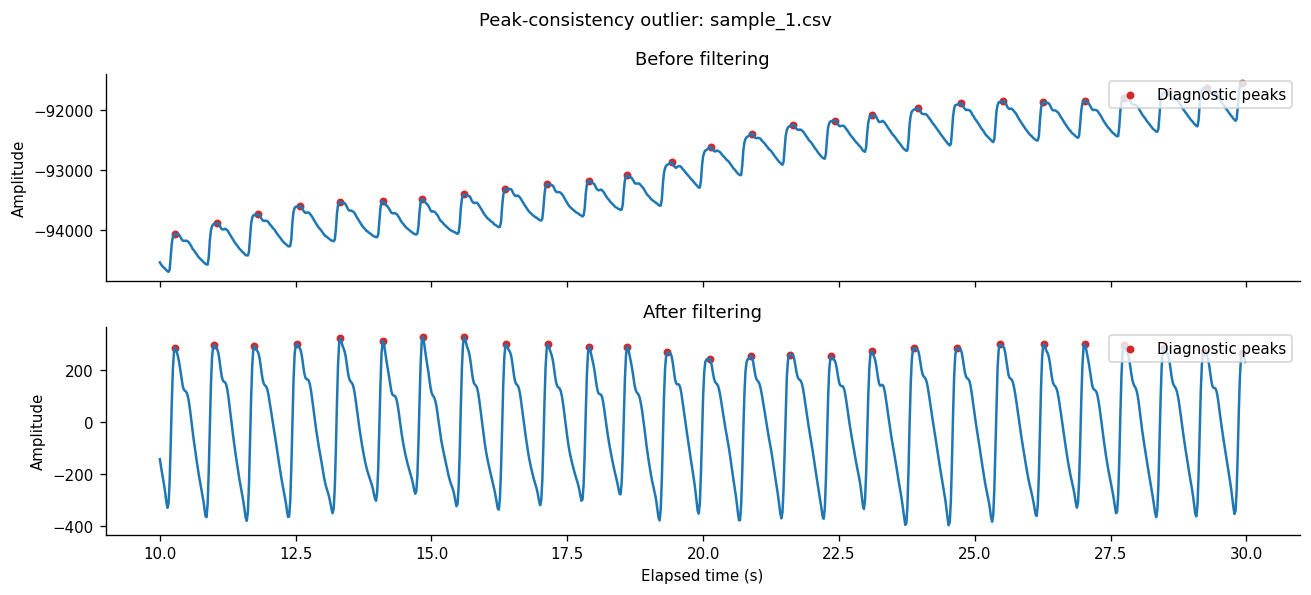

In [11]:
# Cell 10: Inspect representative waveform segments
inspection_names = {
    "Typical": typical_session_name(evaluation_metrics),
}
spectral_outlier_rows = evaluation_metrics[
    evaluation_metrics["Spectral outlier"]
]
peak_outlier_rows = evaluation_metrics[
    evaluation_metrics["Peak-consistency outlier"]
]
if not spectral_outlier_rows.empty:
    inspection_names["Spectral outlier"] = str(
        spectral_outlier_rows.iloc[0]["Session"]
    )
if not peak_outlier_rows.empty:
    inspection_names["Peak-consistency outlier"] = str(
        peak_outlier_rows.iloc[0]["Session"]
    )

for role, session_name in inspection_names.items():
    item = session_lookup[session_name]
    elapsed_s = item["time"] - item["time"][0]
    segment_mask = (elapsed_s >= WAVEFORM_START_S) & (
        elapsed_s <= WAVEFORM_END_S
    )
    segment_indices = np.flatnonzero(segment_mask)
    if segment_indices.size == 0:
        print(f"Skipping {session_name}: requested segment is unavailable.")
        continue
    start_index, end_index = segment_indices[[0, -1]]
    before_peaks = item["peaks_before"]
    after_peaks = item["peaks_after"]
    before_peaks = before_peaks[
        (before_peaks >= start_index) & (before_peaks <= end_index)
    ]
    after_peaks = after_peaks[
        (after_peaks >= start_index) & (after_peaks <= end_index)
    ]
    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    axes[0].plot(elapsed_s[segment_mask], item["inverted"][segment_mask])
    axes[0].scatter(
        elapsed_s[before_peaks],
        item["inverted"][before_peaks],
        color="tab:red",
        s=14,
        label="Diagnostic peaks",
    )
    axes[0].set_title("Before filtering")
    axes[1].plot(elapsed_s[segment_mask], item["filtered"][segment_mask])
    axes[1].scatter(
        elapsed_s[after_peaks],
        item["filtered"][after_peaks],
        color="tab:red",
        s=14,
        label="Diagnostic peaks",
    )
    axes[1].set_title("After filtering")
    for axis in axes:
        axis.set_ylabel("Amplitude")
        axis.legend(loc="upper right")
    axes[1].set_xlabel("Elapsed time (s)")
    fig.suptitle(f"{role}: {session_name}")
    fig.tight_layout()
    plt.show()

In [12]:
# Cell 11: Compare metrics between sampling-rate groups
comparison_columns = [
    "In-band retention",
    "Low-frequency ratio",
    "High-frequency ratio",
    "Peak-count change (%)",
    "Peak match rate (%)",
]
comparison_rows = []
for group_name in ("25 Hz", "50 Hz"):
    group = evaluation_metrics[
        evaluation_metrics["Sampling rate"] == group_name
    ]
    for row in summarize_metrics(group, comparison_columns).to_dict("records"):
        row["Sampling rate"] = group_name
        row["Sessions"] = len(group)
        comparison_rows.append(row)
sampling_rate_comparison = pd.DataFrame(comparison_rows)
sampling_rate_comparison = sampling_rate_comparison[[
    "Sampling rate",
    "Sessions",
    "Metric",
    "Median",
    "IQR",
    "Min",
    "Max",
]]
display(sampling_rate_comparison.style.format({
    column: "{:.4f}" for column in ["Median", "IQR", "Min", "Max"]
}).hide(axis="index"))

Sampling rate,Sessions,Metric,Median,IQR,Min,Max
25 Hz,19,In-band retention,0.9776,0.0088,0.9454,0.9875
25 Hz,19,Low-frequency ratio,0.0037,0.0018,0.0012,0.0082
25 Hz,19,High-frequency ratio,0.0652,0.0094,0.0535,0.0782
25 Hz,19,Peak-count change (%),3.2192,7.1225,0.2312,692.2591
25 Hz,19,Peak match rate (%),99.9490,0.1063,99.3605,100.0000
50 Hz,1,In-band retention,0.9630,0.0000,0.9630,0.9630
50 Hz,1,Low-frequency ratio,0.0015,0.0000,0.0015,0.0015
50 Hz,1,High-frequency ratio,0.1060,0.0000,0.1060,0.1060
50 Hz,1,Peak-count change (%),41.5053,0.0000,41.5053,41.5053
50 Hz,1,Peak match rate (%),98.8996,0.0000,98.8996,98.8996


In [13]:
# Cell 12: Build the final filter summary
final_columns = [
    "In-band retention",
    "Low-frequency ratio",
    "High-frequency ratio",
    "Peak-count change (%)",
    "Peak match rate (%)",
    "Median timing shift (ms)",
]
final_summary = summarize_metrics(evaluation_metrics, final_columns)
display(final_summary.style.format({
    column: "{:.4f}" for column in ["Median", "IQR", "Min", "Max"]
}).hide(axis="index"))

spectral_outlier_count = int(evaluation_metrics["Spectral outlier"].sum())
peak_outlier_count = int(
    evaluation_metrics["Peak-consistency outlier"].sum()
)
run_summary = pd.DataFrame({
    "Item": [
        "Sessions filtered without error",
        "Spectral outliers",
        "Peak-consistency outliers",
    ],
    "Count": [
        len(filtered_sessions),
        spectral_outlier_count,
        peak_outlier_count,
    ],
})
display(run_summary.style.hide(axis="index"))
manual_review_required = spectral_outlier_count > 0 or peak_outlier_count > 0
if manual_review_required:
    print(
        "Conclusion: review the flagged sessions before freezing the filter "
        "parameters."
    )
else:
    print(
        "Conclusion: no IQR outliers were detected; confirm the plots before "
        "freezing the filter parameters."
    )

Metric,Median,IQR,Min,Max
In-band retention,0.9774,0.0091,0.9454,0.9875
Low-frequency ratio,0.0035,0.0019,0.0012,0.0082
High-frequency ratio,0.0655,0.0103,0.0535,0.1060
Peak-count change (%),3.9543,7.3014,0.2312,692.2591
Peak match rate (%),99.9427,0.1244,98.8996,100.0000
Median timing shift (ms),0.0000,0.0000,0.0000,0.0000


Item,Count
Sessions filtered without error,20
Spectral outliers,3
Peak-consistency outliers,4


Conclusion: review the flagged sessions before freezing the filter parameters.


Diagnostic plausible HR range: 40--180 bpm
Highlighted rows are previously identified outlier sessions.


Session,Windows,Before Median,After Median,Before Mean,After Mean,Before SD,After SD,Before IQR,After IQR,Before Min,After Min,Before Max,After Max,Before Implausible (%),After Implausible (%)
sample_1.csv,39,64.0,81.0,58.2,81.8,24.1,2.9,37.0,3.5,5.0,76.0,84.0,92.0,23.1,0.0
sample_4.csv,50,81.0,84.0,80.7,84.5,3.4,5.9,5.5,7.8,75.0,75.0,87.0,99.0,0.0,0.0
sample_5.csv,60,4.0,83.0,10.5,82.4,14.0,4.5,10.2,6.2,1.0,74.0,53.0,93.0,91.7,0.0
sample_6.csv,52,75.0,76.0,75.2,77.0,3.7,5.9,6.0,7.2,68.0,69.0,83.0,92.0,0.0,0.0
sample_7.csv,53,84.0,96.0,85.2,97.9,5.7,12.0,4.0,11.0,77.0,81.0,101.0,126.0,0.0,0.0
sample_8.csv,51,76.0,77.0,75.6,77.9,3.4,5.2,3.0,7.5,68.0,68.0,86.0,91.0,0.0,0.0
sample_9.csv,79,91.0,93.0,86.4,93.9,12.7,3.9,8.0,4.5,34.0,85.0,100.0,106.0,2.5,0.0
sample_10.csv,40,73.0,73.0,73.0,75.3,4.3,8.6,5.2,6.5,65.0,66.0,84.0,103.0,0.0,0.0
sample_11.csv,41,77.0,77.0,76.3,77.7,4.0,5.3,4.0,6.0,65.0,65.0,84.0,88.0,0.0,0.0
sample_12.csv,60,92.0,96.0,92.5,98.3,3.1,7.9,5.0,7.2,86.0,88.0,98.0,123.0,0.0,0.0


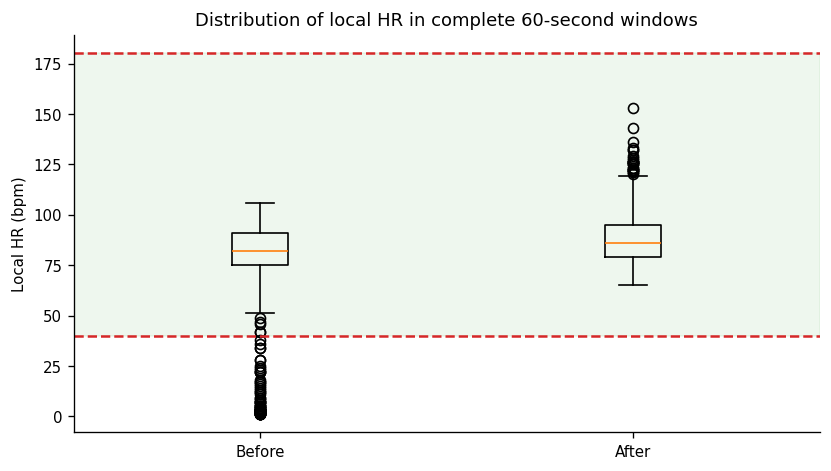

Diagnostic only; this is not the final PPI peak detector.


In [14]:
# Diagnostic: Compare local heart rate before and after filtering
HR_WINDOW_S = 60.0
PLAUSIBLE_HR_MIN_BPM = 40.0
PLAUSIBLE_HR_MAX_BPM = 180.0
KNOWN_OUTLIER_SESSIONS = {
    "sample_1.csv",
    "sample_5.csv",
    "sample_14.csv",
    "sample_23.csv",
}


def calculate_window_hr(
    peak_indices: np.ndarray,
    time_s: np.ndarray,
) -> np.ndarray:
    """Calculate HR in complete non-overlapping windows."""
    elapsed_s = time_s - time_s[0]
    window_count = int(np.floor(elapsed_s[-1] / HR_WINDOW_S))
    if window_count == 0:
        return np.array([], dtype=float)
    window_edges = np.arange(window_count + 1) * HR_WINDOW_S
    peak_times_s = elapsed_s[peak_indices]
    peak_times_s = peak_times_s[peak_times_s < window_edges[-1]]
    peak_counts, _ = np.histogram(peak_times_s, bins=window_edges)
    return peak_counts / HR_WINDOW_S * 60.0


def summarize_local_hr(values: np.ndarray) -> dict[str, float]:
    """Summarize local HR values."""
    first_quartile, third_quartile = np.quantile(values, [0.25, 0.75])
    implausible = (values < PLAUSIBLE_HR_MIN_BPM) | (
        values > PLAUSIBLE_HR_MAX_BPM
    )
    return {
        "Median": float(np.median(values)),
        "Mean": float(np.mean(values)),
        "SD": float(np.std(values, ddof=1)),
        "IQR": float(third_quartile - first_quartile),
        "Min": float(np.min(values)),
        "Max": float(np.max(values)),
        "Implausible (%)": float(100.0 * np.mean(implausible)),
    }


local_hr_rows = []
local_hr_values = {"Before": [], "After": []}
for item in filtered_sessions:
    before_hr = calculate_window_hr(
        item["peaks_before"], item["time"]
    )
    after_hr = calculate_window_hr(
        item["peaks_after"], item["time"]
    )
    if before_hr.size == 0 or after_hr.size == 0:
        continue
    before_summary = summarize_local_hr(before_hr)
    after_summary = summarize_local_hr(after_hr)
    row = {
        "Session": item["session"],
        "Windows": len(before_hr),
    }
    for metric in before_summary:
        row[f"Before {metric}"] = before_summary[metric]
        row[f"After {metric}"] = after_summary[metric]
    local_hr_rows.append(row)
    local_hr_values["Before"].extend(before_hr)
    local_hr_values["After"].extend(after_hr)

local_hr_comparison = pd.DataFrame(local_hr_rows)
hr_format = {
    column: "{:.1f}"
    for column in local_hr_comparison.columns
    if column not in {"Session", "Windows"}
}


def highlight_known_outliers(row: pd.Series) -> list[str]:
    """Highlight previously identified outlier sessions."""
    color = (
        "background-color: #fff2cc"
        if row["Session"] in KNOWN_OUTLIER_SESSIONS
        else ""
    )
    return [color] * len(row)


print(
    f"Diagnostic plausible HR range: {PLAUSIBLE_HR_MIN_BPM:.0f}--"
    f"{PLAUSIBLE_HR_MAX_BPM:.0f} bpm"
)
print("Highlighted rows are previously identified outlier sessions.")
display(
    local_hr_comparison.style
    .format(hr_format)
    .apply(highlight_known_outliers, axis=1)
    .hide(axis="index")
)

fig, axis = plt.subplots(figsize=(7, 4))
axis.boxplot(
    [local_hr_values["Before"], local_hr_values["After"]],
    tick_labels=["Before", "After"],
    showfliers=True,
)
axis.axhspan(
    PLAUSIBLE_HR_MIN_BPM,
    PLAUSIBLE_HR_MAX_BPM,
    color="tab:green",
    alpha=0.08,
)
axis.axhline(PLAUSIBLE_HR_MIN_BPM, color="tab:red", linestyle="--")
axis.axhline(PLAUSIBLE_HR_MAX_BPM, color="tab:red", linestyle="--")
axis.set_title("Distribution of local HR in complete 60-second windows")
axis.set_ylabel("Local HR (bpm)")
fig.tight_layout()
plt.show()
print("Diagnostic only; this is not the final PPI peak detector.")

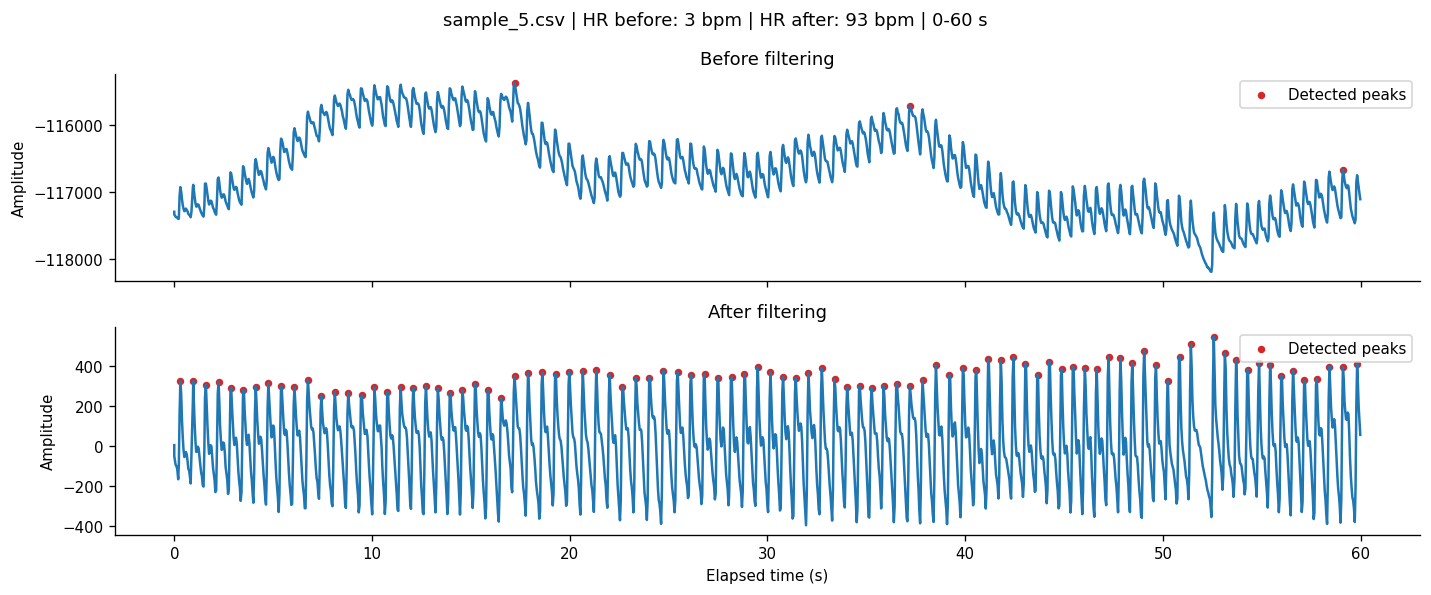

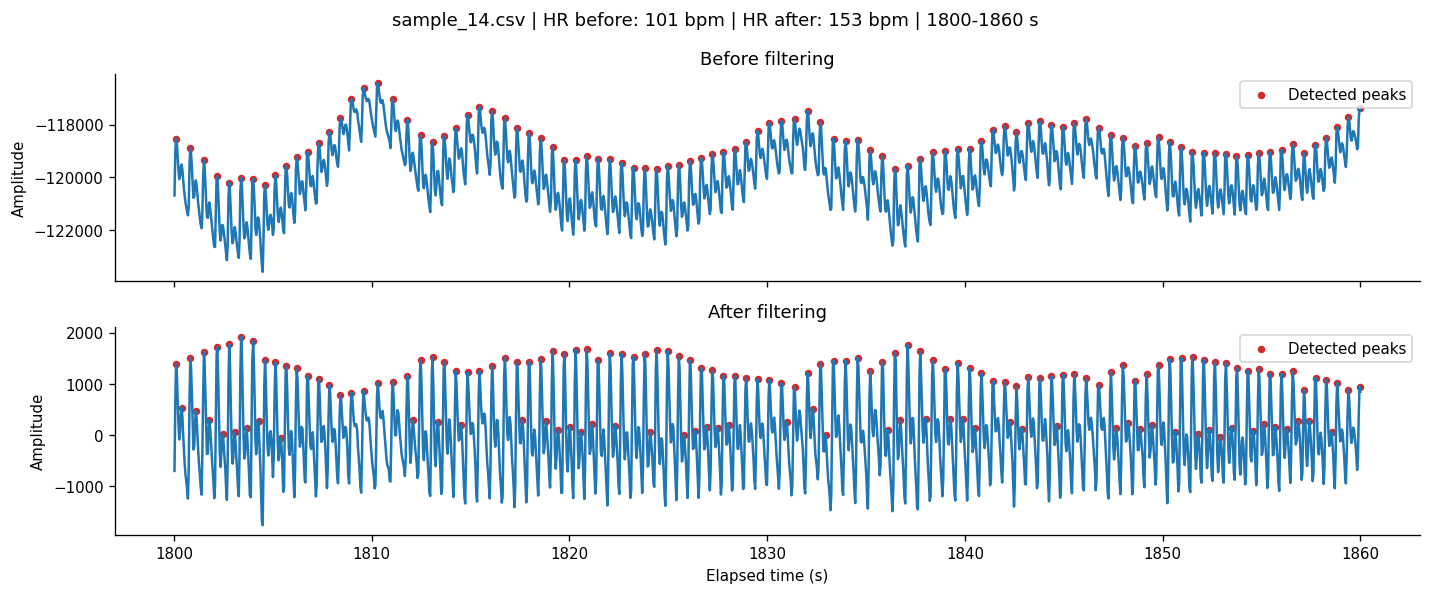

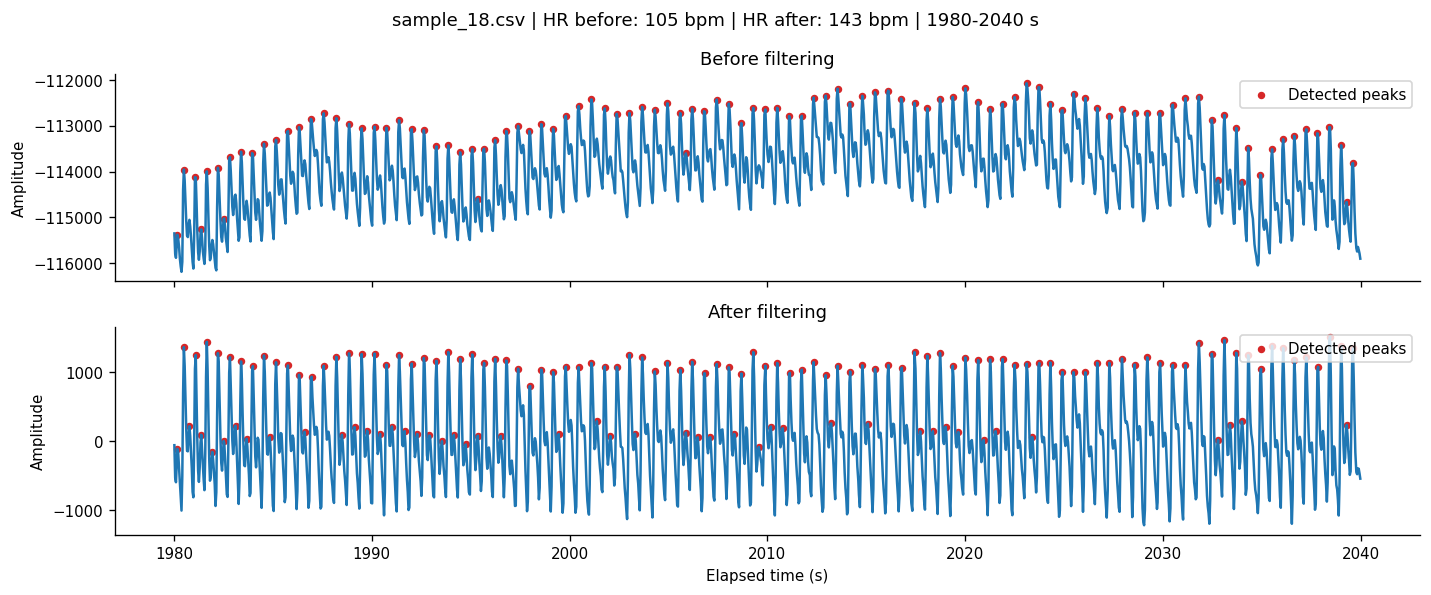

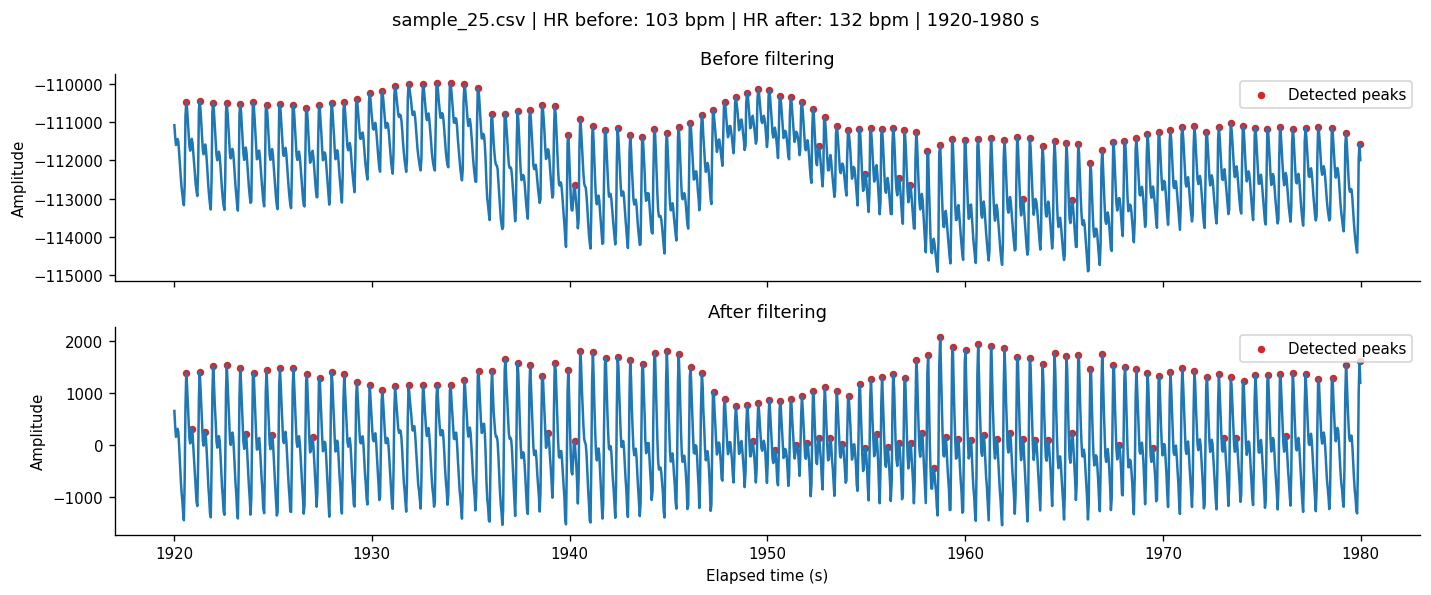

Inspect the plots for double-peaks, ringing, and false peak generation.


In [15]:
# Final diagnostic 1: Inspect high-HR windows in targeted sessions
TARGETED_SESSIONS = [
    "sample_5.csv",
    "sample_14.csv",
    "sample_18.csv",
    "sample_25.csv",
]
targeted_windows = {}

for session_name in TARGETED_SESSIONS:
    item = session_lookup[session_name]
    elapsed_s = item["time"] - item["time"][0]
    before_hr = calculate_window_hr(
        item["peaks_before"], item["time"]
    )
    after_hr = calculate_window_hr(
        item["peaks_after"], item["time"]
    )
    window_index = int(np.argmax(after_hr))
    window_start_s = window_index * HR_WINDOW_S
    window_end_s = window_start_s + HR_WINDOW_S
    window_mask = (elapsed_s >= window_start_s) & (
        elapsed_s < window_end_s
    )
    before_peaks = item["peaks_before"]
    after_peaks = item["peaks_after"]
    before_peak_mask = (elapsed_s[before_peaks] >= window_start_s) & (
        elapsed_s[before_peaks] < window_end_s
    )
    after_peak_mask = (elapsed_s[after_peaks] >= window_start_s) & (
        elapsed_s[after_peaks] < window_end_s
    )
    before_window_peaks = before_peaks[before_peak_mask]
    after_window_peaks = after_peaks[after_peak_mask]
    targeted_windows[session_name] = {
        "start_s": window_start_s,
        "end_s": window_end_s,
        "before_hr": before_hr[window_index],
        "after_hr": after_hr[window_index],
    }

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(elapsed_s[window_mask], item["inverted"][window_mask])
    axes[0].scatter(
        elapsed_s[before_window_peaks],
        item["inverted"][before_window_peaks],
        color="tab:red",
        s=12,
        label="Detected peaks",
    )
    axes[0].set_title("Before filtering")
    axes[1].plot(elapsed_s[window_mask], item["filtered"][window_mask])
    axes[1].scatter(
        elapsed_s[after_window_peaks],
        item["filtered"][after_window_peaks],
        color="tab:red",
        s=12,
        label="Detected peaks",
    )
    axes[1].set_title("After filtering")
    for axis in axes:
        axis.set_ylabel("Amplitude")
        axis.legend(loc="upper right")
    axes[1].set_xlabel("Elapsed time (s)")
    fig.suptitle(
        f"{session_name} | HR before: {before_hr[window_index]:.0f} bpm | "
        f"HR after: {after_hr[window_index]:.0f} bpm | "
        f"{window_start_s:.0f}-{window_end_s:.0f} s"
    )
    fig.tight_layout()
    plt.show()

print(
    "Inspect the plots for double-peaks, ringing, and false peak generation."
)

In [16]:
# Final diagnostic 2: Compare PPI plausibility before and after filtering
PPI_MIN_S = 0.30
PPI_MAX_S = 1.50


def calculate_ppi(
    peak_indices: np.ndarray,
    time_s: np.ndarray,
) -> np.ndarray:
    """Convert diagnostic peak times to PPI values."""
    return np.diff(time_s[peak_indices])


def summarize_ppi(values: np.ndarray) -> dict[str, float]:
    """Summarize PPI values and diagnostic plausibility."""
    first_quartile, third_quartile = np.quantile(values, [0.25, 0.75])
    implausible = (values < PPI_MIN_S) | (values > PPI_MAX_S)
    return {
        "Median PPI (s)": float(np.median(values)),
        "IQR PPI (s)": float(third_quartile - first_quartile),
        "Min PPI (s)": float(np.min(values)),
        "Max PPI (s)": float(np.max(values)),
        "Implausible PPI (%)": float(100.0 * np.mean(implausible)),
    }


ppi_rows = []
for item in filtered_sessions:
    before_ppi = calculate_ppi(item["peaks_before"], item["time"])
    after_ppi = calculate_ppi(item["peaks_after"], item["time"])
    before_summary = summarize_ppi(before_ppi)
    after_summary = summarize_ppi(after_ppi)
    row = {"Session": item["session"]}
    for metric in before_summary:
        row[f"Before {metric}"] = before_summary[metric]
        row[f"After {metric}"] = after_summary[metric]
    ppi_rows.append(row)

ppi_comparison = pd.DataFrame(ppi_rows)
ppi_format = {
    column: "{:.3f}"
    for column in ppi_comparison.columns
    if column != "Session"
}
print(f"Diagnostic plausible PPI range: {PPI_MIN_S:.2f}-{PPI_MAX_S:.2f} s")
display(
    ppi_comparison.style
    .format(ppi_format)
    .hide(axis="index")
)

dataset_ppi_plausibility = pd.DataFrame({
    "Stage": ["Before", "After"],
    "Median implausible PPI (%)": [
        ppi_comparison["Before Implausible PPI (%)"].median(),
        ppi_comparison["After Implausible PPI (%)"].median(),
    ],
})
display(
    dataset_ppi_plausibility.style
    .format({"Median implausible PPI (%)": "{:.3f}"})
    .hide(axis="index")
)
print("Diagnostic only; this is not the final PPI preprocessing rule.")

Diagnostic plausible PPI range: 0.30-1.50 s


Session,Before Median PPI (s),After Median PPI (s),Before IQR PPI (s),After IQR PPI (s),Before Min PPI (s),After Min PPI (s),Before Max PPI (s),After Max PPI (s),Before Implausible PPI (%),After Implausible PPI (%)
sample_1.csv,0.740,0.740,0.100,0.060,0.540,0.340,23.180,1.640,5.900,0.031
sample_4.csv,0.729,0.720,0.089,0.090,0.280,0.270,1.610,1.490,0.074,4.363
sample_5.csv,0.880,0.720,4.050,0.080,0.560,0.319,89.809,1.839,39.715,0.219
sample_6.csv,0.800,0.800,0.081,0.081,0.280,0.270,1.050,1.050,0.075,2.111
sample_7.csv,0.720,0.690,0.080,0.320,0.271,0.270,1.490,0.931,2.487,14.904
sample_8.csv,0.800,0.800,0.082,0.111,0.279,0.271,1.010,1.010,0.051,2.399
sample_9.csv,0.640,0.640,0.080,0.080,0.479,0.073,13.770,1.560,1.477,0.040
sample_10.csv,0.839,0.810,0.119,0.120,0.280,0.270,1.650,1.360,0.136,2.759
sample_11.csv,0.771,0.770,0.110,0.119,0.319,0.271,1.681,1.681,0.159,1.936
sample_12.csv,0.641,0.640,0.071,0.080,0.279,0.271,1.769,1.050,0.144,5.874


Stage,Median implausible PPI (%)
Before,0.431
After,2.255


Diagnostic only; this is not the final PPI preprocessing rule.


Configuration,Passband retention,Low-frequency suppression,High-frequency suppression,Peak-count change (%),Peak match rate (%),Implausible HR windows (%),Implausible PPI (%)
0.5-6 Hz,0.9706,0.9966,0.9161,1.69,99.95,0.00,1.14
0.5-8 Hz,0.9774,0.9965,0.9345,3.95,99.94,0.00,2.26
0.5-10 Hz,0.9784,0.9964,0.9522,5.46,99.97,0.00,2.73


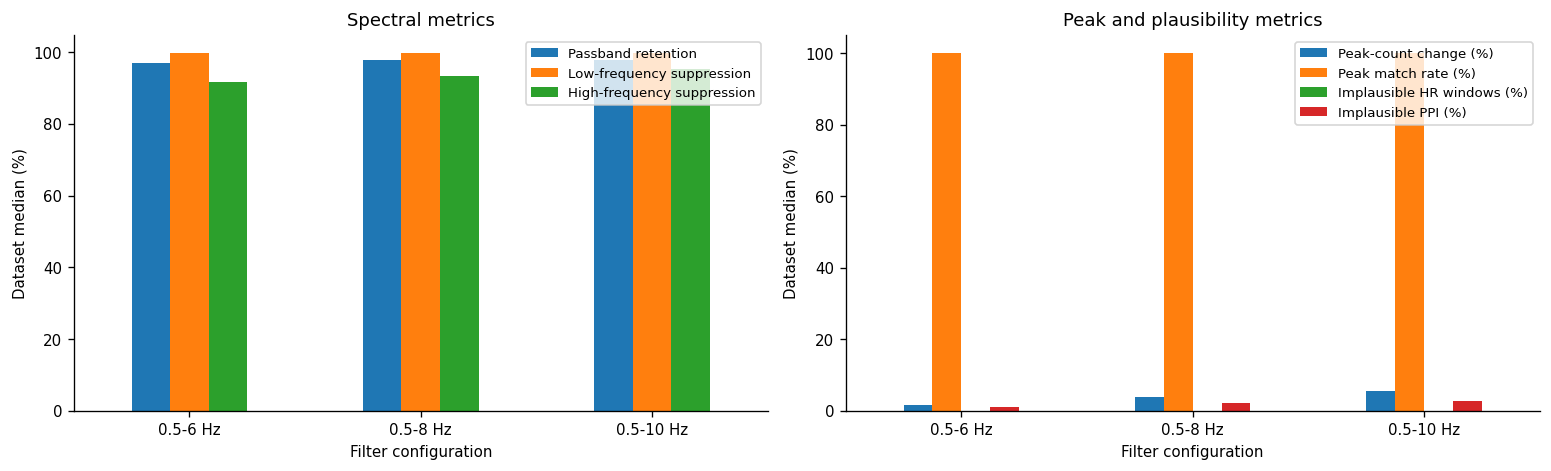

Final diagnostic summary
- sample_14.csv: Additional peaks consistent with double-peaking are visible; no obvious sustained ringing.
- sample_18.csv: Additional peaks consistent with double-peaking are visible; no obvious sustained ringing.
- sample_25.csv: Additional peaks consistent with double-peaking are visible; no obvious sustained ringing.
- PPI plausibility does not improve: dataset median implausible PPI changes from 0.43% to 2.26%.
- Directional conclusions stable across configurations: Yes. Median peak-count change is 1.69% to 5.46%; median implausible HR is 0.00% to 0.00%; median implausible PPI is 1.14% to 2.73%.
No filter configuration is selected automatically.


In [17]:
# Final diagnostic 3: Compare filter configurations
FILTER_CONFIGURATIONS = {
    "0.5-6 Hz": (0.5, 6.0),
    "0.5-8 Hz": (0.5, 8.0),
    "0.5-10 Hz": (0.5, 10.0),
}


def percentage_outside_range(
    values: np.ndarray,
    lower: float,
    upper: float,
) -> float:
    """Calculate the percentage outside an inclusive range."""
    if values.size == 0:
        return np.nan
    return float(100.0 * np.mean((values < lower) | (values > upper)))


sensitivity_rows = []
for configuration, (lowcut_hz, highcut_hz) in FILTER_CONFIGURATIONS.items():
    session_rows = []
    for item in filtered_sessions:
        is_reference_filter = (
            lowcut_hz == LOWCUT_HZ and highcut_hz == HIGHCUT_HZ
        )
        if is_reference_filter:
            candidate_signal = item["filtered"]
            candidate_peaks = item["peaks_after"]
        else:
            _, candidate_signal = preprocess_ppg(
                item["raw"],
                item["fs"],
                lowcut=lowcut_hz,
                highcut=highcut_hz,
                order=FILTER_ORDER,
            )
            candidate_peaks = detect_diagnostic_peaks(
                candidate_signal, item["fs"]
            )
        frequencies, before_psd = estimate_psd(
            item["inverted"], item["fs"]
        )
        _, after_psd = estimate_psd(candidate_signal, item["fs"])
        masks = {
            "passband": (frequencies >= lowcut_hz)
            & (frequencies <= highcut_hz),
            "low": frequencies < lowcut_hz,
            "high": frequencies > highcut_hz,
        }
        before_power = {
            name: integrate_band(frequencies, before_psd, mask)
            for name, mask in masks.items()
        }
        after_power = {
            name: integrate_band(frequencies, after_psd, mask)
            for name, mask in masks.items()
        }
        before_count = len(item["peaks_before"])
        peak_count_change = (
            100.0 * (len(candidate_peaks) - before_count) / before_count
        )
        matched_shifts = match_peak_times(
            item["time"][item["peaks_before"]],
            item["time"][candidate_peaks],
            PEAK_MATCH_TOLERANCE_S,
        )
        peak_match_rate = 100.0 * len(matched_shifts) / before_count
        candidate_hr = calculate_window_hr(candidate_peaks, item["time"])
        candidate_ppi = calculate_ppi(candidate_peaks, item["time"])
        session_rows.append({
            "Passband retention": power_ratio(
                after_power["passband"], before_power["passband"]
            ),
            "Low-frequency suppression": 1.0 - power_ratio(
                after_power["low"], before_power["low"]
            ),
            "High-frequency suppression": 1.0 - power_ratio(
                after_power["high"], before_power["high"]
            ),
            "Peak-count change (%)": peak_count_change,
            "Peak match rate (%)": peak_match_rate,
            "Implausible HR windows (%)": percentage_outside_range(
                candidate_hr,
                PLAUSIBLE_HR_MIN_BPM,
                PLAUSIBLE_HR_MAX_BPM,
            ),
            "Implausible PPI (%)": percentage_outside_range(
                candidate_ppi, PPI_MIN_S, PPI_MAX_S
            ),
        })
    session_metrics = pd.DataFrame(session_rows)
    row = {"Configuration": configuration}
    row.update(session_metrics.median().to_dict())
    sensitivity_rows.append(row)

filter_sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_format = {
    "Passband retention": "{:.4f}",
    "Low-frequency suppression": "{:.4f}",
    "High-frequency suppression": "{:.4f}",
    "Peak-count change (%)": "{:.2f}",
    "Peak match rate (%)": "{:.2f}",
    "Implausible HR windows (%)": "{:.2f}",
    "Implausible PPI (%)": "{:.2f}",
}
display(
    filter_sensitivity.style
    .format(sensitivity_format)
    .hide(axis="index")
)

spectral_plot = filter_sensitivity.set_index("Configuration")[[
    "Passband retention",
    "Low-frequency suppression",
    "High-frequency suppression",
]] * 100.0
diagnostic_plot = filter_sensitivity.set_index("Configuration")[[
    "Peak-count change (%)",
    "Peak match rate (%)",
    "Implausible HR windows (%)",
    "Implausible PPI (%)",
]]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
spectral_plot.plot.bar(ax=axes[0], rot=0)
diagnostic_plot.plot.bar(ax=axes[1], rot=0)
axes[0].set_title("Spectral metrics")
axes[0].set_ylabel("Dataset median (%)")
axes[1].set_title("Peak and plausibility metrics")
axes[1].set_ylabel("Dataset median (%)")
for axis in axes:
    axis.set_xlabel("Filter configuration")
    axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

VISUAL_INSPECTION_FINDINGS = {
    "sample_14.csv": (
        "Additional peaks consistent with double-peaking are visible; "
        "no obvious sustained ringing."
    ),
    "sample_18.csv": (
        "Additional peaks consistent with double-peaking are visible; "
        "no obvious sustained ringing."
    ),
    "sample_25.csv": (
        "Additional peaks consistent with double-peaking are visible; "
        "no obvious sustained ringing."
    ),
}
before_ppi_rate = dataset_ppi_plausibility.loc[
    dataset_ppi_plausibility["Stage"] == "Before",
    "Median implausible PPI (%)",
].iloc[0]
after_ppi_rate = dataset_ppi_plausibility.loc[
    dataset_ppi_plausibility["Stage"] == "After",
    "Median implausible PPI (%)",
].iloc[0]
before_hr_rate = local_hr_comparison["Before Implausible (%)"].median()
peak_changes = filter_sensitivity["Peak-count change (%)"]
hr_rate_changes = (
    filter_sensitivity["Implausible HR windows (%)"] - before_hr_rate
)
ppi_rate_changes = (
    filter_sensitivity["Implausible PPI (%)"] - before_ppi_rate
)
stable_direction = (
    ((peak_changes >= 0).all() or (peak_changes <= 0).all())
    and ((hr_rate_changes >= 0).all() or (hr_rate_changes <= 0).all())
    and ((ppi_rate_changes >= 0).all() or (ppi_rate_changes <= 0).all())
)
print("Final diagnostic summary")
for session_name, finding in VISUAL_INSPECTION_FINDINGS.items():
    print(f"- {session_name}: {finding}")
ppi_direction = "improves" if after_ppi_rate < before_ppi_rate else "does not improve"
print(
    f"- PPI plausibility {ppi_direction}: dataset median implausible PPI "
    f"changes from {before_ppi_rate:.2f}% to {after_ppi_rate:.2f}%."
)
stability_text = "Yes" if stable_direction else "No"
print(
    f"- Directional conclusions stable across configurations: "
    f"{stability_text}. Median peak-count change is "
    f"{peak_changes.min():.2f}% to {peak_changes.max():.2f}%; median "
    f"implausible HR is "
    f"{filter_sensitivity['Implausible HR windows (%)'].min():.2f}% to "
    f"{filter_sensitivity['Implausible HR windows (%)'].max():.2f}%; "
    f"median implausible PPI is "
    f"{filter_sensitivity['Implausible PPI (%)'].min():.2f}% to "
    f"{filter_sensitivity['Implausible PPI (%)'].max():.2f}%."
)
print("No filter configuration is selected automatically.")

## Tổng kết kết quả

### Dữ liệu và quá trình lọc

- Notebook đọc thành công **20/20 session** và lọc thành công cả 20 session.
- Không ghi nhận lỗi filtering, thay đổi số mẫu hoặc giá trị `NaN`/`Inf` sau lọc.
- Dataset gồm **1 session xấp xỉ 50 Hz** (`sample_1.csv`) và **19 session xấp xỉ 25 Hz**.
- Số mẫu mỗi session nằm trong khoảng **60.386--119.272 mẫu**; thời lượng nằm trong khoảng **2.356,54--4.747,33 giây**.
- Tín hiệu trước khi lọc trong các phép so sánh là PPG sau optical inversion; trục thời gian và label không bị thay đổi.

### Kết quả phổ công suất

| Metric | Median | IQR | Min | Max |
| --- | ---: | ---: | ---: | ---: |
| In-band retention | 0,9774 | 0,0091 | 0,9454 | 0,9875 |
| Low-frequency ratio | 0,0035 | 0,0019 | 0,0012 | 0,0082 |
| High-frequency ratio | 0,0655 | 0,0103 | 0,0535 | 0,1060 |

Median low-frequency suppression là **0,9965** và median high-frequency suppression là **0,9345**. Notebook đã tạo distribution plot cho in-band retention và hai suppression metric, đồng thời vẽ PSD trước/sau lọc với hai mốc **0,5 Hz** và **8 Hz**.

### Kết quả peak

| Metric | Median | IQR | Min | Max |
| --- | ---: | ---: | ---: | ---: |
| Peak-count change (%) | 3,9543 | 7,3014 | 0,2312 | 692,2591 |
| Peak match rate (%) | 99,9427 | 0,1244 | 98,8996 | 100,0000 |
| Median timing shift (ms) | 0,0000 | 0,0000 | 0,0000 | 0,0000 |

Maximum timing shift theo từng session nằm trong khoảng **50,13--100,00 ms**. Diagnostic detector được dùng giống nhau cho tín hiệu trước và sau lọc; đây chưa phải detector chính thức cho PPI.

### Các session được đánh dấu theo ngưỡng 1,5 IQR

- Có **3 spectral outlier**: `sample_1.csv`, `sample_5.csv` và `sample_23.csv`.
- Có **4 peak-consistency outlier**: `sample_1.csv`, `sample_5.csv`, `sample_14.csv` và `sample_23.csv`.
- `sample_1.csv`: high-frequency ratio, peak-count change và peak match rate được đánh dấu; peak match rate là **98,90%**.
- `sample_5.csv`: in-band retention là **0,9454**; peak count thay đổi từ **633** thành **5.015**, tương ứng **692,26%**.
- `sample_14.csv`: peak count thay đổi từ **5.099** thành **6.200**, tương ứng **21,59%**.
- `sample_23.csv`: low-frequency ratio và peak match rate được đánh dấu; peak match rate là **99,36%**.
- Các session trên chỉ được đưa vào danh sách kiểm tra thủ công, không bị loại khỏi dataset.

### So sánh theo sampling rate

| Metric (median) | 25 Hz, n = 19 | 50 Hz, n = 1 |
| --- | ---: | ---: |
| In-band retention | 0,9776 | 0,9630 |
| Low-frequency ratio | 0,0037 | 0,0015 |
| High-frequency ratio | 0,0652 | 0,1060 |
| Peak-count change (%) | 3,2192 | 41,5053 |
| Peak match rate (%) | 99,9490 | 98,8996 |

Notebook cũng đã tạo các waveform plot trong đoạn **10--30 giây**, gồm tín hiệu trước/sau lọc và các diagnostic peak tương ứng.

# CONCLUSION


# Kết luận đánh giá bộ lọc

Bộ lọc đang thử nghiệm:

```text
Butterworth bandpass: 0.5–8 Hz
Order: 2
Zero-phase: filtfilt
````

## Kết quả chính

* Median in-band retention: **97.74%**
* Median low-frequency suppression: **99.65%**
* Median high-frequency suppression: **93.45%**
* Median peak match rate: **99.94%**
* Median timing shift: **0 ms**
* Không phát sinh lỗi filtering, NaN/Inf hoặc thay đổi số mẫu.

## Đánh giá

Bộ lọc cho thấy:

* bảo toàn tốt năng lượng trong dải PPG;
* loại mạnh baseline drift và thành phần tần số cao;
* bảo toàn tốt vị trí temporal của phần lớn pulse;
* hiệu ứng tương đối nhất quán giữa các session.

Peak-count change có một số outlier, đặc biệt `sample_5.csv`, nhưng nhiều khả năng liên quan đến diagnostic peak detector trên tín hiệu chưa lọc hơn là bằng chứng trực tiếp về distortion do filter.

Các session outlier chỉ được kiểm tra thủ công, chưa bị loại.

## Kết luận tạm thời

**Butterworth 0.5–8 Hz, order 2, zero-phase được chấp nhận tạm thời làm bộ lọc chính.**

Trước khi freeze hoàn toàn:

1. kiểm tra waveform/peak của các session outlier;
2. kiểm tra HR ước lượng trước/sau filter để phát hiện peak-detection failure;
3. nếu không xuất hiện distortion đáng kể, freeze filter và chuyển sang SQI.

```

